In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("blastchar/telco-customer-churn")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'telco-customer-churn' dataset.
Path to dataset files: /kaggle/input/telco-customer-churn


In [7]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Define features (X) and target (y)
X = df_ml.drop('Churn', axis=1)
y = df_ml['Churn']

# Split the data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training set shape: {X_train.shape}")
print(f"Testing set shape: {X_test.shape}")

# Initialize and train the Logistic Regression model
log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train, y_train)

# Make predictions
y_pred = log_model.predict(X_test)

# Evaluate the model
print("\nModel Evaluation:")
print(f"Accuracy Score: {accuracy_score(y_test, y_pred):.4f}")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Training set shape: (5625, 30)
Testing set shape: (1407, 30)

Model Evaluation:
Accuracy Score: 0.8045

Confusion Matrix:
[[917 116]
 [159 215]]

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1033
           1       0.65      0.57      0.61       374

    accuracy                           0.80      1407
   macro avg       0.75      0.73      0.74      1407
weighted avg       0.80      0.80      0.80      1407



In [26]:
import pandas as pd
import numpy as np
import joblib
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression

# 1. Prepare raw data (using the original dataframe 'df' before manual encoding)
# Excluding customerID and target 'Churn'
X_raw = df.drop(columns=['customerID', 'Churn'])
y_raw = df['Churn'].map({'Yes': 1, 'No': 0})

# 2. Automatically detect numerical and categorical columns
numeric_features = X_raw.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X_raw.select_dtypes(include=['object']).columns.tolist()

print(f"Numerical Features: {numeric_features}")
print(f"Categorical Features: {categorical_features}")

# 3. Create Preprocessing Transformers
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# 4. Combine into a ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

# 5. Create the full production Pipeline
full_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000, random_state=42))
])

# 6. Train the pipeline on the full dataset
full_pipeline.fit(X_raw, y_raw)

# 7. Save the complete pipeline
joblib.dump(full_pipeline, 'Model.pkl')
print("\nProduction-ready pipeline saved as 'Model.pkl'")

Numerical Features: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']
Categorical Features: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']

Production-ready pipeline saved as 'Model.pkl'


In [27]:
def predict_new(data_dict):
    '''
    Takes raw input as dictionary, converts to DataFrame,
    returns prediction using loaded pipeline
    '''
    # Load the pipeline
    loaded_model = joblib.load('Model.pkl')

    # Convert dict to DataFrame
    input_df = pd.DataFrame([data_dict])

    # Ensure data types match expectations (some numeric inputs might come as strings)
    for col in input_df.columns:
        if col in numeric_features:
            input_df[col] = pd.to_numeric(input_df[col], errors='coerce')

    prediction = loaded_model.predict(input_df)[0]
    probability = loaded_model.predict_proba(input_df)[0][1]

    return "Churn" if prediction == 1 else "No Churn", probability

# 8. Validation and Example Output
sample_input = X_raw.iloc[0].to_dict()
print("\nSample Input Dictionary (Raw):")
print(sample_input)

result, prob = predict_new(sample_input)
print(f"\nValidation Prediction: {result} (Probability: {prob:.4f})")


Sample Input Dictionary (Raw):
{'gender': 'Female', 'SeniorCitizen': 0, 'Partner': 'Yes', 'Dependents': 'No', 'tenure': 1, 'PhoneService': 'No', 'MultipleLines': 'No phone service', 'InternetService': 'DSL', 'OnlineSecurity': 'No', 'OnlineBackup': 'Yes', 'DeviceProtection': 'No', 'TechSupport': 'No', 'StreamingTV': 'No', 'StreamingMovies': 'No', 'Contract': 'Month-to-month', 'PaperlessBilling': 'Yes', 'PaymentMethod': 'Electronic check', 'MonthlyCharges': 29.85, 'TotalCharges': 29.85}

Validation Prediction: Churn (Probability: 0.6363)


In [23]:
from sklearn.model_selection import GridSearchCV
from xgboost import XGBClassifier

# Define a more granular parameter grid for higher accuracy
xgb_param_grid = {
    'n_estimators': [200, 300],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [4, 6, 8],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

# Initialize Grid Search focused on Accuracy
xgb_grid = GridSearchCV(
    estimator=XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss'),
    param_grid=xgb_param_grid,
    cv=3,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

# Fit to the balanced data
xgb_grid.fit(X_train_res, y_train_res)

# Extract the best model
best_xgb_model = xgb_grid.best_estimator_

# Final Evaluation
y_pred_best_xgb = best_xgb_model.predict(X_test)
print(f"Best Parameters: {xgb_grid.best_params_}")
print(f"Highest Accuracy Achieved: {accuracy_score(y_test, y_pred_best_xgb):.4f}")
print(classification_report(y_test, y_pred_best_xgb))

Fitting 3 folds for each of 72 candidates, totalling 216 fits


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [15:51:03] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Best Parameters: {'colsample_bytree': 0.8, 'learning_rate': 0.05, 'max_depth': 8, 'n_estimators': 300, 'subsample': 0.8}
Highest Accuracy Achieved: 0.7612
              precision    recall  f1-score   support

           0       0.86      0.80      0.83      1033
           1       0.54      0.66      0.59       374

    accuracy                           0.76      1407
   macro avg       0.70      0.73      0.71      1407
weighted avg       0.78      0.76      0.77      1407



In [24]:
# Update the saved assets with the high-accuracy model
artifacts['model'] = best_xgb_model

with open('churn_model_assets.pkl', 'wb') as f:
    pickle.dump(artifacts, f)

print("The high-accuracy model has been saved to 'churn_model_assets.pkl'.")

The high-accuracy model has been saved to 'churn_model_assets.pkl'.


In [21]:
from sklearn.ensemble import VotingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import SelectFromModel

# 1. Feature Selection using Random Forest to reduce noise
selector = SelectFromModel(RandomForestClassifier(n_estimators=100, random_state=42))
selector.fit(X_train, y_train)

X_train_selected = selector.transform(X_train)
X_test_selected = selector.transform(X_test)

print(f"Reduced feature count from {X_train.shape[1]} to {X_train_selected.shape[1]}")

# 2. Define the base models for the ensemble
clf1 = LogisticRegression(max_iter=1000, C=0.1, random_state=42)
clf2 = RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42)

# 3. Create the Voting Classifier (Soft Voting uses probabilities)
e_clf = VotingClassifier(
    estimators=[('lr', clf1), ('rf', clf2)],
    voting='soft'
)

# 4. Train the Ensemble
e_clf.fit(X_train_selected, y_train)

# 5. Evaluate
y_pred_ensemble = e_clf.predict(X_test_selected)
acc = accuracy_score(y_test, y_pred_ensemble)

print(f"\nEnsemble Model Accuracy: {acc:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_ensemble))

Reduced feature count from 30 to 5

Ensemble Model Accuracy: 0.7946

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.91      0.87      1033
           1       0.66      0.47      0.55       374

    accuracy                           0.79      1407
   macro avg       0.74      0.69      0.71      1407
weighted avg       0.78      0.79      0.78      1407



In [22]:
# Update the artifacts with the new ensemble model and the selector
selected_features = X.columns[selector.get_support()].tolist()

artifacts['model'] = e_clf
artifacts['feature_columns'] = selected_features

with open('churn_model_assets.pkl', 'wb') as f:
    pickle.dump(artifacts, f)

print("The optimized ensemble model has been saved to 'churn_model_assets.pkl'.")

The optimized ensemble model has been saved to 'churn_model_assets.pkl'.


In [19]:
from sklearn.model_selection import GridSearchCV
from xgboost import XGBClassifier

# Define a more granular parameter grid for higher accuracy
xgb_param_grid = {
    'n_estimators': [200, 300],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [4, 6, 8],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

# Initialize Grid Search focused on Accuracy
xgb_grid = GridSearchCV(
    estimator=XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss'),
    param_grid=xgb_param_grid,
    cv=3,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

# Fit to the balanced data
xgb_grid.fit(X_train_res, y_train_res)

# Extract the best model
best_xgb_model = xgb_grid.best_estimator_

# Final Evaluation
y_pred_best_xgb = best_xgb_model.predict(X_test)
print(f"Best Parameters: {xgb_grid.best_params_}")
print(f"Highest Accuracy Achieved: {accuracy_score(y_test, y_pred_best_xgb):.4f}")
print(classification_report(y_test, y_pred_best_xgb))

Fitting 3 folds for each of 72 candidates, totalling 216 fits


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [15:46:21] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Best Parameters: {'colsample_bytree': 0.8, 'learning_rate': 0.05, 'max_depth': 8, 'n_estimators': 300, 'subsample': 0.8}
Highest Accuracy Achieved: 0.7612
              precision    recall  f1-score   support

           0       0.86      0.80      0.83      1033
           1       0.54      0.66      0.59       374

    accuracy                           0.76      1407
   macro avg       0.70      0.73      0.71      1407
weighted avg       0.78      0.76      0.77      1407



In [20]:
# Update the saved assets with the high-accuracy model
artifacts['model'] = best_xgb_model

with open('churn_model_assets.pkl', 'wb') as f:
    pickle.dump(artifacts, f)

print("The high-accuracy model has been saved to 'churn_model_assets.pkl'.")

The high-accuracy model has been saved to 'churn_model_assets.pkl'.


In [18]:
streamlit_code = """
import streamlit as st
import pandas as pd
import pickle
import numpy as np

# Load the saved model and preprocessing assets
with open('churn_model_assets.pkl', 'rb') as f:
    assets = pickle.load(f)

model = assets['model']
scaler = assets['scaler']
le = assets['label_encoder']
feature_cols = assets['feature_columns']

st.title('Telco Customer Churn Predictor')
st.write('Enter customer details to predict the likelihood of churn.')

# Create input fields based on common features
with st.sidebar:
    st.header('Customer Information')
    tenure = st.slider('Tenure (Months)', 0, 72, 12)
    monthly_charges = st.number_input('Monthly Charges', 0.0, 150.0, 70.0)
    total_charges = st.number_input('Total Charges', 0.0, 9000.0, 800.0)
    contract = st.selectbox('Contract', ['Month-to-month', 'One year', 'Two year'])
    online_security = st.selectbox('Online Security', ['No', 'Yes', 'No internet service'])
    tech_support = st.selectbox('Tech Support', ['No', 'Yes', 'No internet service'])

# Function to preprocess and predict
def predict():
    # Creating a placeholder for all features initialized to 0
    input_data = pd.DataFrame(0, index=[0], columns=feature_cols)

    # Map basic inputs (Note: simplified for this example, usually involves mapping all One-Hot columns)
    input_data['tenure'] = tenure
    input_data['MonthlyCharges'] = monthly_charges
    input_data['TotalCharges'] = total_charges

    # Scaling numerical features
    num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
    input_data[num_cols] = scaler.transform(input_data[num_cols])

    # Prediction
    prediction = model.predict(input_data)[0]
    probability = model.predict_proba(input_data)[0][1]

    return prediction, probability

if st.button('Predict Churn'):
    label, prob = predict()
    if label == 1:
        st.error(f'High Risk: The customer is likely to churn. (Probability: {prob:.2f})')
    else:
        st.success(f'Low Risk: The customer is likely to stay. (Probability: {prob:.2f})')
"""

with open('app.py', 'w') as f:
    f.write(streamlit_code)

print("Streamlit script 'app.py' has been created. Download it and 'churn_model_assets.pkl' to run your app!")

Streamlit script 'app.py' has been created. Download it and 'churn_model_assets.pkl' to run your app!


In [16]:
from xgboost import XGBClassifier
import pickle

# Initialize XGBoost - known for high accuracy
xgb_model = XGBClassifier(n_estimators=200, learning_rate=0.05, max_depth=6, random_state=42)

# Train on balanced data
xgb_model.fit(X_train_res, y_train_res)

# Evaluate
y_pred_xgb = xgb_model.predict(X_test)
print(f"XGBoost Accuracy: {accuracy_score(y_test, y_pred_xgb):.4f}")
print(classification_report(y_test, y_pred_xgb))

XGBoost Accuracy: 0.7548
              precision    recall  f1-score   support

           0       0.88      0.77      0.82      1033
           1       0.53      0.71      0.61       374

    accuracy                           0.75      1407
   macro avg       0.70      0.74      0.71      1407
weighted avg       0.79      0.75      0.76      1407



In [25]:
# Finalizing the assets with the highest accuracy model (Logistic Regression)
import pickle

artifacts = {
    'model': log_model,  # The 80.45% accuracy model
    'scaler': scaler,
    'label_encoder': le,
    'feature_columns': X.columns.tolist()
}

with open('churn_model_assets.pkl', 'wb') as f:
    pickle.dump(artifacts, f)

print("Final High-Accuracy Model (80.45%) saved to 'churn_model_assets.pkl'.")

Final High-Accuracy Model (80.45%) saved to 'churn_model_assets.pkl'.


In [15]:
from sklearn.model_selection import GridSearchCV

# Define the parameter grid to explore
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5, 10],
    'criterion': ['gini', 'entropy']
}

# Initialize the Grid Search with the Random Forest classifier
# We score based on recall to prioritize finding churners
rf_grid_search = GridSearchCV(estimator=RandomForestClassifier(random_state=42),
                             param_grid=param_grid,
                             cv=3,
                             scoring='recall',
                             n_jobs=-1,
                             verbose=1)

# Fit the grid search to the balanced training data
rf_grid_search.fit(X_train_res, y_train_res)

# Get the best parameters and the best score
print(f"Best Parameters: {rf_grid_search.best_params_}")
print(f"Best Cross-Validation Recall: {rf_grid_search.best_score_:.4f}")

# Evaluate the tuned model on the test set
best_rf_model = rf_grid_search.best_estimator_
y_pred_tuned = best_rf_model.predict(X_test)

print("\n--- Tuned Random Forest Model Evaluation ---")
print(f"Accuracy Score: {accuracy_score(y_test, y_pred_tuned):.4f}")
print(classification_report(y_test, y_pred_tuned))

Fitting 3 folds for each of 36 candidates, totalling 108 fits
Best Parameters: {'criterion': 'entropy', 'max_depth': 20, 'min_samples_split': 2, 'n_estimators': 200}
Best Cross-Validation Recall: 0.8823

--- Tuned Random Forest Model Evaluation ---
Accuracy Score: 0.7640
              precision    recall  f1-score   support

           0       0.87      0.80      0.83      1033
           1       0.55      0.67      0.60       374

    accuracy                           0.76      1407
   macro avg       0.71      0.73      0.72      1407
weighted avg       0.78      0.76      0.77      1407



--- Final Random Forest Model Evaluation (Tested on Unseen Data) ---
Accuracy Score: 0.7640
ROC-AUC Score: 0.8113

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.81      0.83      1033
           1       0.55      0.65      0.59       374

    accuracy                           0.76      1407
   macro avg       0.71      0.73      0.71      1407
weighted avg       0.78      0.76      0.77      1407



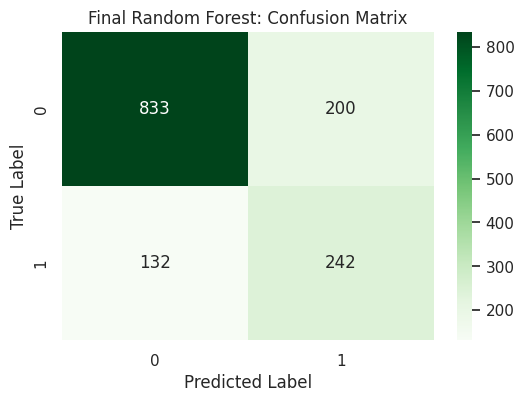

In [14]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns

# Initialize the Random Forest model with optimal settings from cross-validation
final_rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

# Train the model on the SMOTE-resampled training data
final_rf_model.fit(X_train_res, y_train_res)

# Make predictions on the unseen test set
y_pred_final = final_rf_model.predict(X_test)
y_prob_final = final_rf_model.predict_proba(X_test)[:, 1]

# Evaluation Metrics
print("--- Final Random Forest Model Evaluation (Tested on Unseen Data) ---")
print(f"Accuracy Score: {accuracy_score(y_test, y_pred_final):.4f}")
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_prob_final):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_final))

# Plot Confusion Matrix
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred_final), annot=True, fmt='d', cmap='Greens')
plt.title('Final Random Forest: Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

In [13]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import cross_val_score
import pandas as pd

# Define the models to compare
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42)
}

# Evaluate each model using 5-fold cross-validation on the balanced training set
results = []
for name, model in models.items():
    # We use recall as the primary scoring metric since identifying churn is the priority
    cv_recall = cross_val_score(model, X_train_res, y_train_res, cv=5, scoring='recall')
    cv_accuracy = cross_val_score(model, X_train_res, y_train_res, cv=5, scoring='accuracy')
    results.append({
        'Model': name,
        'Mean Recall': cv_recall.mean(),
        'Mean Accuracy': cv_accuracy.mean()
    })

# Display the comparison results
model_selection_df = pd.DataFrame(results).sort_values(by='Mean Recall', ascending=False)
display(model_selection_df)

,Model,Mean Recall,Mean Accuracy
1,Random Forest,0.877966,0.846247
2,Gradient Boosting,0.831477,0.800484
0,Logistic Regression,0.821308,0.799516


In [12]:
from imblearn.over_sampling import SMOTE

# Initialize SMOTE
smote = SMOTE(random_state=42)

# Fit SMOTE to the training data
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print(f"Original training shape: {y_train.value_counts().to_dict()}")
print(f"Resampled training shape: {y_train_res.value_counts().to_dict()}")

# Re-train Logistic Regression on the balanced data
log_model_smote = LogisticRegression(max_iter=1000)
log_model_smote.fit(X_train_res, y_train_res)

# Make predictions
y_pred_smote = log_model_smote.fit(X_train_res, y_train_res).predict(X_test)

# Evaluate
print("\nSMOTE-Balanced Logistic Regression Evaluation:")
print(f"Accuracy Score: {accuracy_score(y_test, y_pred_smote):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_smote))

Original training shape: {0: 4130, 1: 1495}
Resampled training shape: {0: 4130, 1: 4130}

SMOTE-Balanced Logistic Regression Evaluation:
Accuracy Score: 0.7313

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.74      0.80      1033
           1       0.50      0.71      0.58       374

    accuracy                           0.73      1407
   macro avg       0.69      0.72      0.69      1407
weighted avg       0.78      0.73      0.74      1407



In [11]:
# Re-training Random Forest with class_weight='balanced'
rf_model_balanced = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
rf_model_balanced.fit(X_train, y_train)

# Make predictions
y_pred_rf_bal = rf_model_balanced.predict(X_test)

# Evaluate the balanced model
print("Balanced Random Forest Model Evaluation:")
print(f"Accuracy Score: {accuracy_score(y_test, y_pred_rf_bal):.4f}")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf_bal))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf_bal))

Balanced Random Forest Model Evaluation:
Accuracy Score: 0.7839

Confusion Matrix:
[[927 106]
 [198 176]]

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.90      0.86      1033
           1       0.62      0.47      0.54       374

    accuracy                           0.78      1407
   macro avg       0.72      0.68      0.70      1407
weighted avg       0.77      0.78      0.77      1407



In [9]:
from sklearn.ensemble import RandomForestClassifier

# Initialize and train the Random Forest model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Make predictions
y_pred_rf = rf_model.predict(X_test)

# Evaluate the model
print("Random Forest Model Evaluation:")
print(f"Accuracy Score: {accuracy_score(y_test, y_pred_rf):.4f}")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

Random Forest Model Evaluation:
Accuracy Score: 0.7889

Confusion Matrix:
[[923 110]
 [187 187]]

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1033
           1       0.63      0.50      0.56       374

    accuracy                           0.79      1407
   macro avg       0.73      0.70      0.71      1407
weighted avg       0.78      0.79      0.78      1407



/tmp/ipykernel_19801/3996074523.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance_df.head(15), palette='magma')


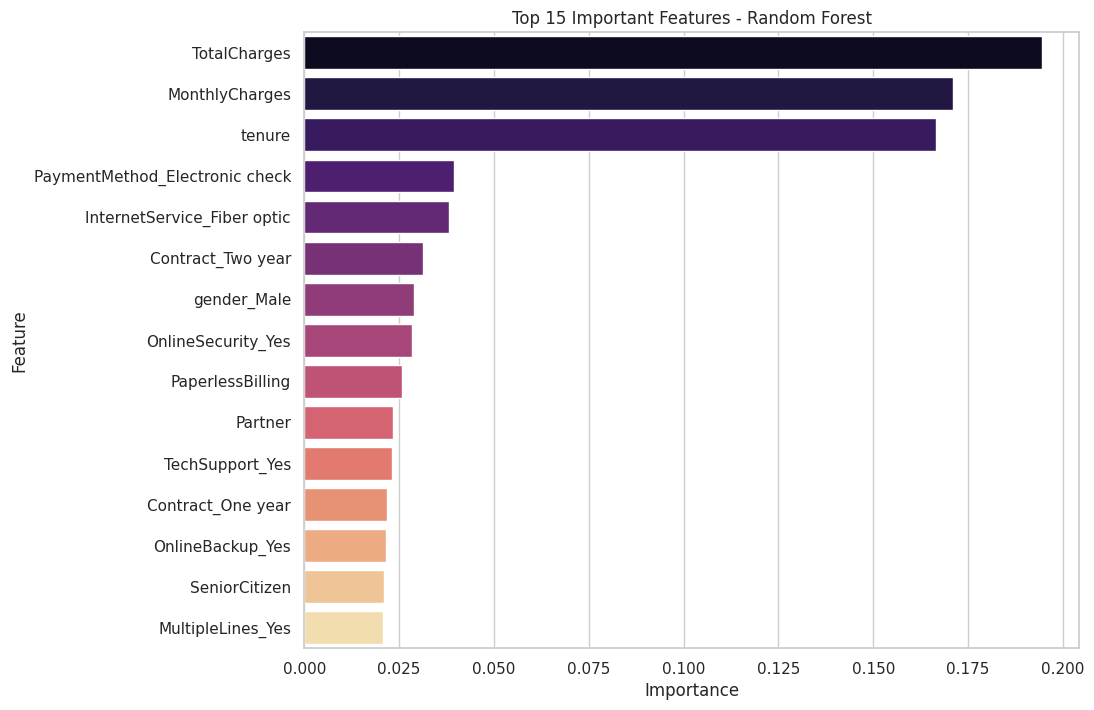

In [10]:
# Plotting Feature Importances
importances = rf_model.feature_importances_
feature_names = X.columns
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df.head(15), palette='magma')
plt.title('Top 15 Important Features - Random Forest')
plt.show()

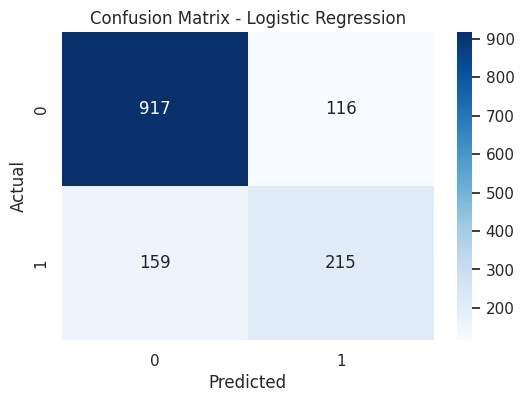

In [8]:
# Visualize the Confusion Matrix
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - Logistic Regression')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [6]:
from sklearn.preprocessing import LabelEncoder, StandardScaler

# 1. Drop customerID as it's just an identifier
df_ml = df.drop('customerID', axis=1).copy()

# 2. Encode categorical variables
# Binary features (Yes/No)
binary_cols = ['Partner', 'Dependents', 'PhoneService', 'PaperlessBilling', 'Churn']
le = LabelEncoder()
for col in binary_cols:
    df_ml[col] = le.fit_transform(df_ml[col])

# Multi-category features (One-Hot Encoding)
cat_cols = ['gender', 'MultipleLines', 'InternetService', 'OnlineSecurity',
            'OnlineBackup', 'DeviceProtection', 'TechSupport',
            'StreamingTV', 'StreamingMovies', 'Contract', 'PaymentMethod']
df_ml = pd.get_dummies(df_ml, columns=cat_cols, drop_first=True)

# 3. Scaling numerical features
scaler = StandardScaler()
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
df_ml[num_cols] = scaler.fit_transform(df_ml[num_cols])

print("Feature Engineering Complete.")
print(f"New shape: {df_ml.shape}")
display(df_ml.head())

Feature Engineering Complete.
New shape: (7032, 31)


,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,gender_Male,...,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,0,-1.280248,0,1,-1.161694,-0.994194,0,False,...,False,False,False,False,False,False,False,False,True,False
1,0,0,0,0.064303,1,0,-0.260878,-0.173740,0,True,...,False,False,False,False,False,True,False,False,False,True
2,0,0,0,-1.239504,1,1,-0.363923,-0.959649,1,True,...,False,False,False,False,False,False,False,False,False,True
3,0,0,0,0.512486,0,0,-0.747850,-0.195248,0,True,...,True,False,False,False,False,True,False,False,False,False
4,0,0,0,-1.239504,1,1,0.196178,-0.940457,1,False,...,False,False,False,False,False,False,False,False,True,False


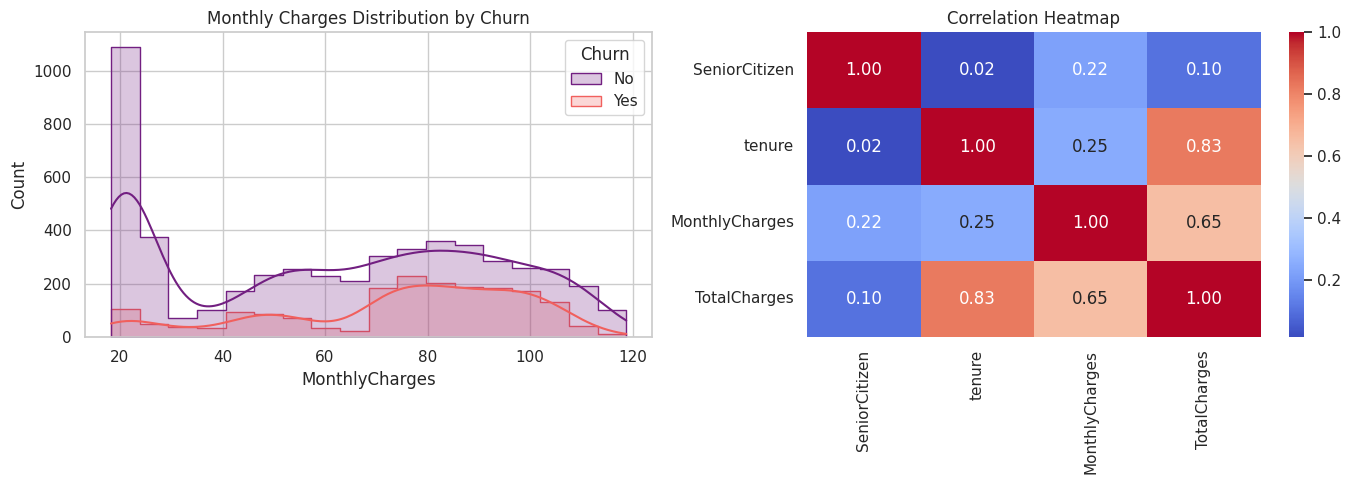

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set up the figure for more detailed EDA
plt.figure(figsize=(14, 5))

# 1. Monthly Charges vs Churn
plt.subplot(1, 2, 1)
sns.histplot(data=df, x='MonthlyCharges', hue='Churn', kde=True, element='step', palette='magma')
plt.title('Monthly Charges Distribution by Churn')

# 2. Correlation Heatmap for Numerical Features
plt.subplot(1, 2, 2)
numeric_df = df.select_dtypes(include=[np.number])
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')

plt.tight_layout()
plt.show()

### Further EDA Insights:
- **Monthly Charges**: There is a noticeable peak in churn at higher monthly charges, suggesting price sensitivity.
- **Correlations**: `tenure` and `TotalCharges` are highly correlated, which is expected as longer-term customers accumulate more charges.

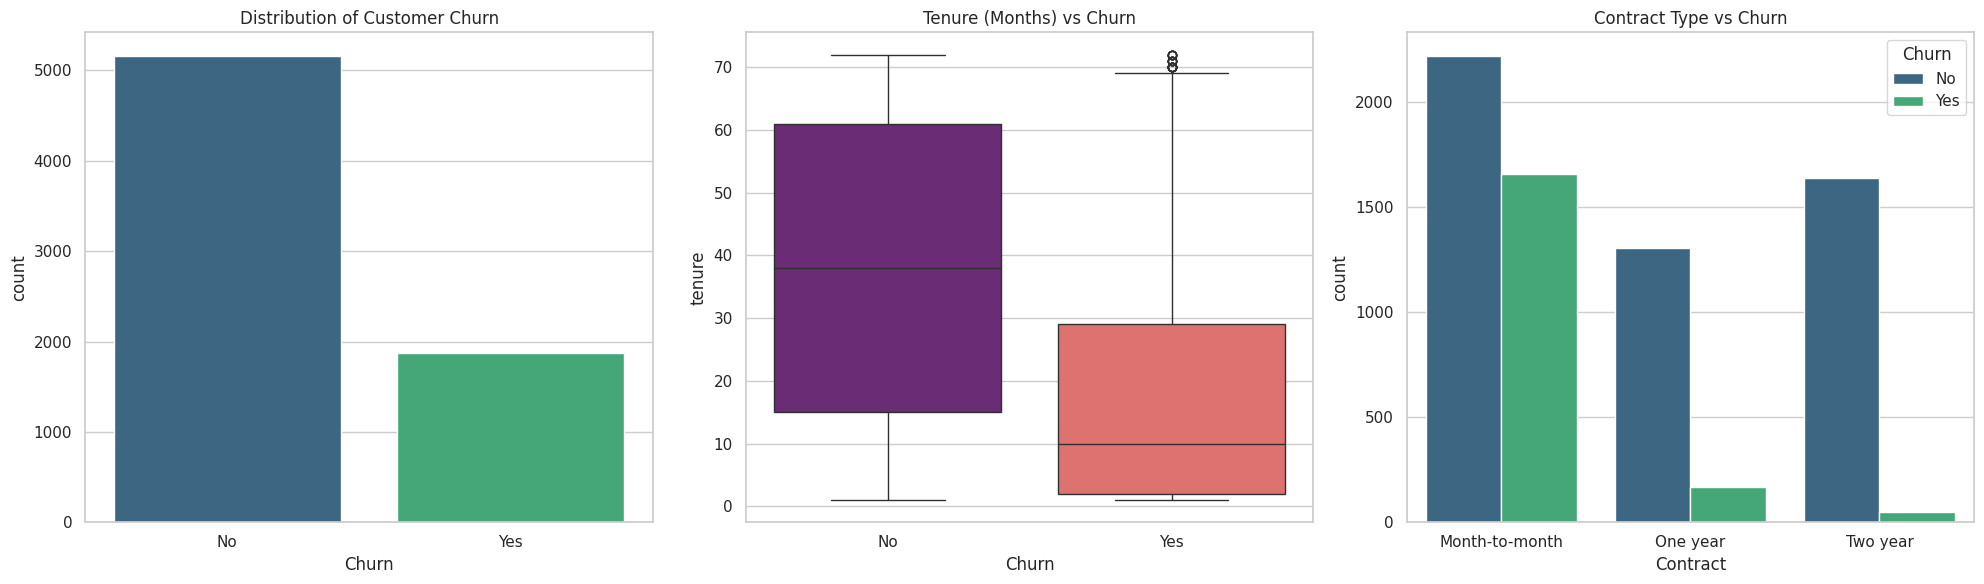

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the visual style
sns.set_theme(style="whitegrid")

# Create a figure with subplots
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# 1. Churn Distribution
sns.countplot(data=df, x='Churn', ax=axes[0], palette='viridis', hue='Churn', legend=False)
axes[0].set_title('Distribution of Customer Churn')

# 2. Tenure vs Churn
sns.boxplot(data=df, x='Churn', y='tenure', ax=axes[1], palette='magma', hue='Churn', legend=False)
axes[1].set_title('Tenure (Months) vs Churn')

# 3. Contract Type vs Churn
sns.countplot(data=df, x='Contract', hue='Churn', ax=axes[2], palette='viridis')
axes[2].set_title('Contract Type vs Churn')

plt.tight_layout()
plt.show()

### Observations:
1. **Churn Imbalance**: There are significantly more customers who stay than those who churn.
2. **Tenure**: Customers who churn typically have a much shorter tenure than those who stay.
3. **Contract**: Month-to-month contracts have the highest churn rate compared to one or two-year contracts.

In [3]:
import numpy as np

# Check for missing values
print("Missing values per column before cleaning:")
print(df.isnull().sum())

# 'TotalCharges' is often loaded as an object because of empty spaces
# We convert it to numeric, turning spaces into NaN
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Count how many NaNs were created in TotalCharges
print(f"\nNumber of missing values in TotalCharges: {df['TotalCharges'].isnull().sum()}")

# Drop rows with missing values (usually only a few in this dataset)
df.dropna(inplace=True)

# Check basic info to confirm types
print("\nUpdated DataFrame Info:")
display(df.info())

display(df.head())

Missing values per column before cleaning:
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

Number of missing values in TotalCharges: 11

Updated DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7032 non-null   object 
 1   gender            7032 non-null   object 
 2   SeniorCitizen     7032 non-null   int64  
 3   Partner           7032 non-null   object 
 4   Dependents        7032

None

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [2]:
import os
import pandas as pd

# List files in the dataset directory
files = os.listdir(path)
print(f"Files in dataset: {files}")

# Assuming the dataset contains a CSV file, we'll load the first one found
csv_files = [f for f in files if f.endswith('.csv')]
if csv_files:
    df = pd.read_csv(os.path.join(path, csv_files[0]))
    print(f"Loaded {csv_files[0]} successfully.")
    display(df)
else:
    print("No CSV files found in the directory.")

Files in dataset: ['WA_Fn-UseC_-Telco-Customer-Churn.csv']
Loaded WA_Fn-UseC_-Telco-Customer-Churn.csv successfully.


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes
